Imports


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

Load Dataset

In [4]:
features = pd.read_csv(
    "../data/raw/elliptic_txs_features.csv",
    header=None
)

classes = pd.read_csv(
    "../data/raw/elliptic_txs_classes.csv"
)

Rename Columns

In [5]:
columns = ["tx_id", "time_step"]

for i in range(2, features.shape[1]):
    columns.append(f"feature_{i-1}")

features.columns = columns

Merge Data

In [6]:
df = features.merge(
    classes,
    left_on="tx_id",
    right_on="txId",
    how="left"
)

df.drop(columns=["txId"], inplace=True)

print(df.shape)
df.head()

(166380, 168)


,tx_id,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_157,feature_158,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown


Dataset Overview

In [7]:
print("Total Transactions:", len(df))

Total Transactions: 166380


In [8]:
print("Number of Features:", len(df.columns))

Number of Features: 168


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166380 entries, 0 to 166379
Columns: 168 entries, tx_id to class
dtypes: float64(165), int64(2), object(1)
memory usage: 213.3+ MB


Class Distribution


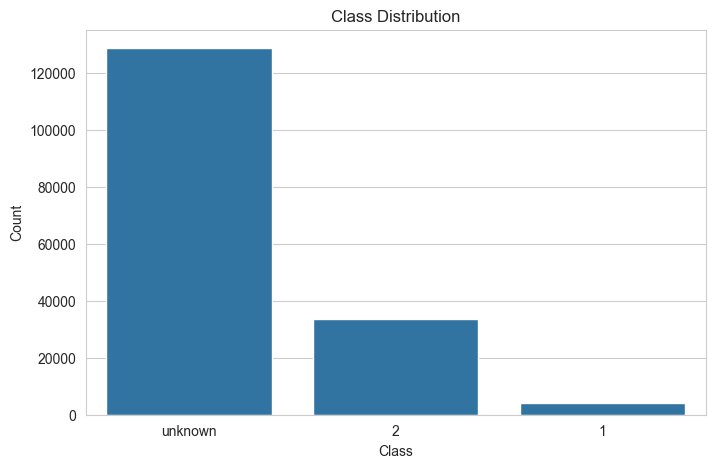

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="class",
    data=df
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig("../reports/figures/class_distribution.png")

plt.show()

In [11]:
class_percentages = (
    df["class"]
    .value_counts(normalize=True)
    * 100
)

print(class_percentages)

class
unknown    77.404736
2          20.123813
1           2.471451
Name: proportion, dtype: float64


Missing Values

In [12]:
missing = df.isnull().sum()

missing = missing[
    missing > 0
]

missing.sort_values(
    ascending=False
)

feature_122    1
feature_123    1
feature_146    1
feature_147    1
feature_148    1
feature_149    1
feature_150    1
feature_151    1
feature_152    1
feature_153    1
feature_154    1
feature_155    1
feature_156    1
feature_157    1
feature_158    1
feature_159    1
feature_160    1
feature_161    1
feature_162    1
feature_163    1
feature_164    1
feature_145    1
feature_144    1
feature_143    1
feature_132    1
feature_124    1
feature_125    1
feature_126    1
feature_127    1
feature_128    1
feature_129    1
feature_130    1
feature_131    1
feature_133    1
feature_142    1
feature_134    1
feature_135    1
feature_136    1
feature_137    1
feature_138    1
feature_139    1
feature_140    1
feature_141    1
feature_165    1
dtype: int64

Plot Missing Columns

In [ ]:
missing.sort_values().plot(
    kind="barh"
)

plt.title("Missing Values per Column")

plt.tight_layout()

plt.savefig(
    "../reports/figures/missing_values.png"
)

plt.show()

Time Step Analysis

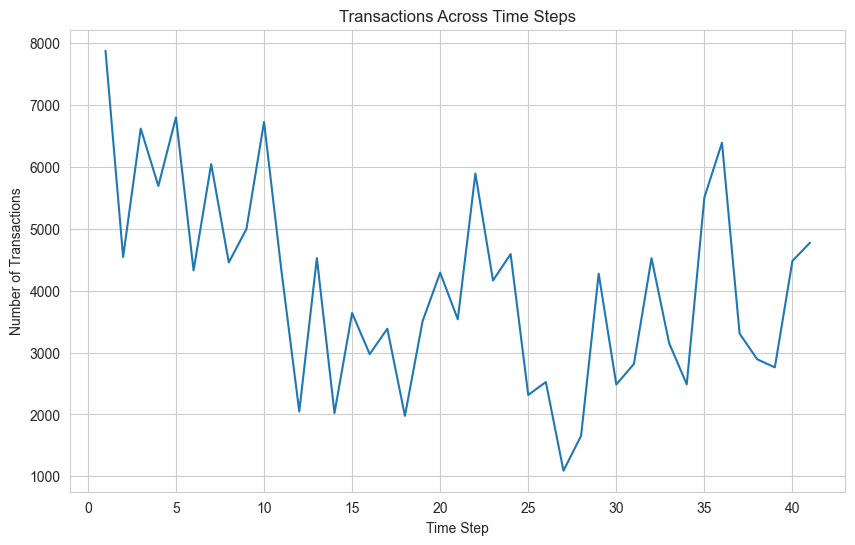

In [13]:
df["time_step"].value_counts().sort_index().plot()

plt.title(
    "Transactions Across Time Steps"
)

plt.xlabel("Time Step")
plt.ylabel("Number of Transactions")

plt.savefig(
    "../reports/figures/time_activity.png"
)

plt.show()

Fraud Evolution

In [14]:
labeled_df = df[
    df["class"] != "unknown"
]

In [15]:
label_map = {
    "1": "Fraud",
    "2": "Legitimate"
}

labeled_df["class"] = (
    labeled_df["class"]
    .astype(str)
)

C:\Users\santh_6hyokkp\AppData\Local\Temp\ipykernel_20940\1105606742.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labeled_df["class"] = (


In [16]:
fraud_per_time = (
    labeled_df[
        labeled_df["class"] == "1"
    ]
    .groupby("time_step")
    .size()
)

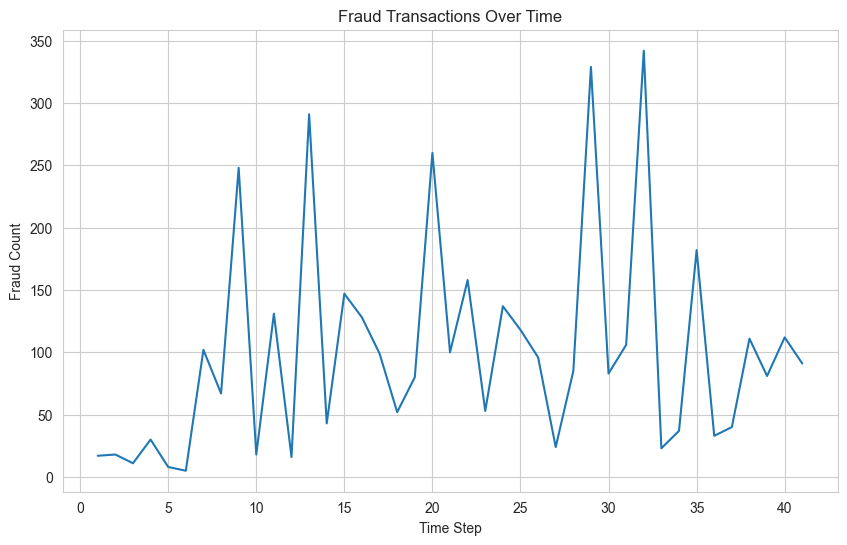

In [17]:
fraud_per_time.plot()

plt.title(
    "Fraud Transactions Over Time"
)

plt.xlabel("Time Step")
plt.ylabel("Fraud Count")

plt.savefig(
    "../reports/figures/fraud_over_time.png"
)

plt.show()

Feature Distributions

In [18]:
selected_features = [
    "feature_1",
    "feature_10",
    "feature_50",
    "feature_100"
]

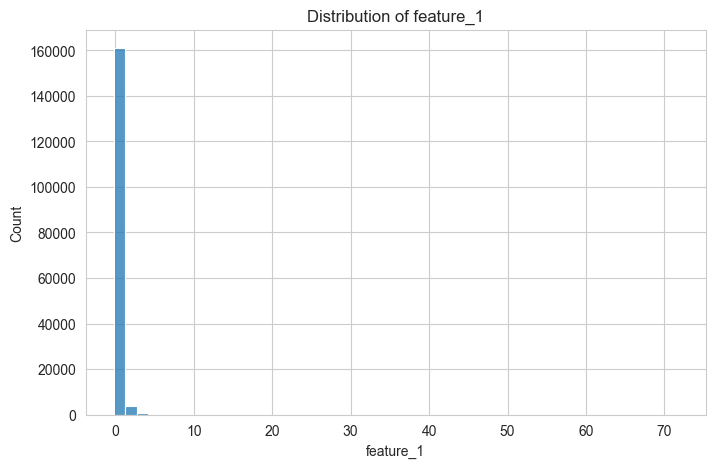

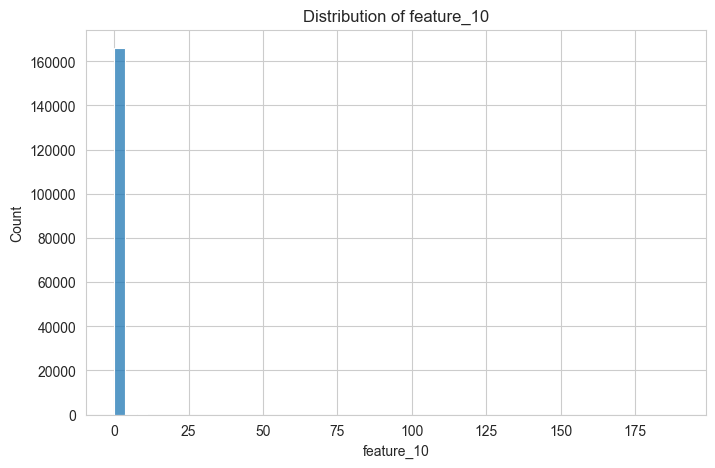

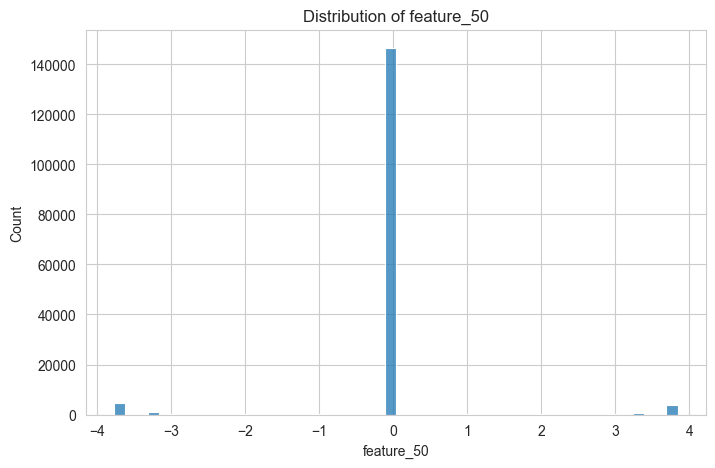

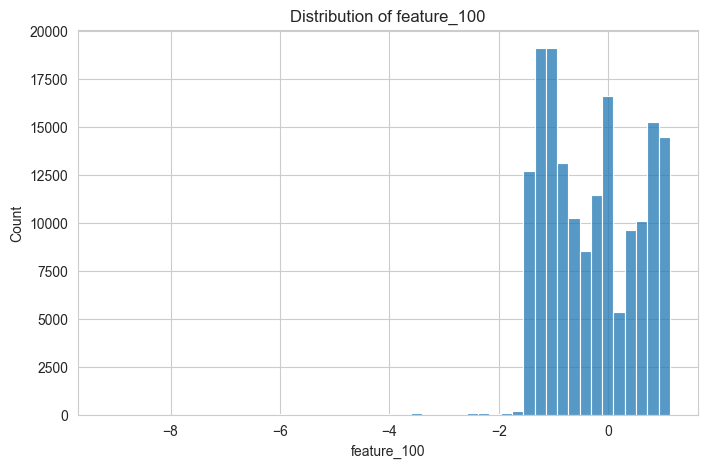

In [19]:
for feature in selected_features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        df[feature],
        bins=50
    )

    plt.title(
        f"Distribution of {feature}"
    )

    plt.show()

Fraud vs Legitimate Feature Comparison

In [20]:
labeled_df = df[
    df["class"] != "unknown"
]

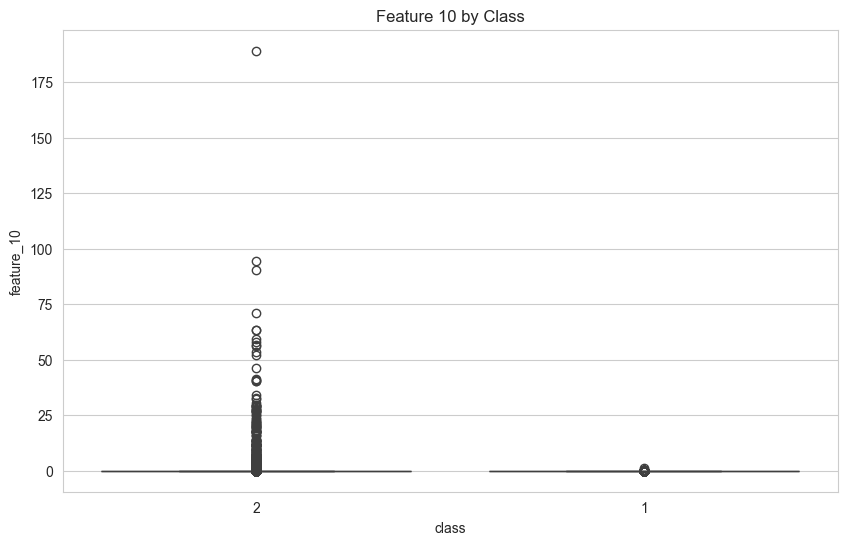

In [21]:
sns.boxplot(
    x="class",
    y="feature_10",
    data=labeled_df
)

plt.title(
    "Feature 10 by Class"
)

plt.show()

Correlation Analysis

In [22]:
corr = df[
    [f"feature_{i}" for i in range(1,21)]
].corr()

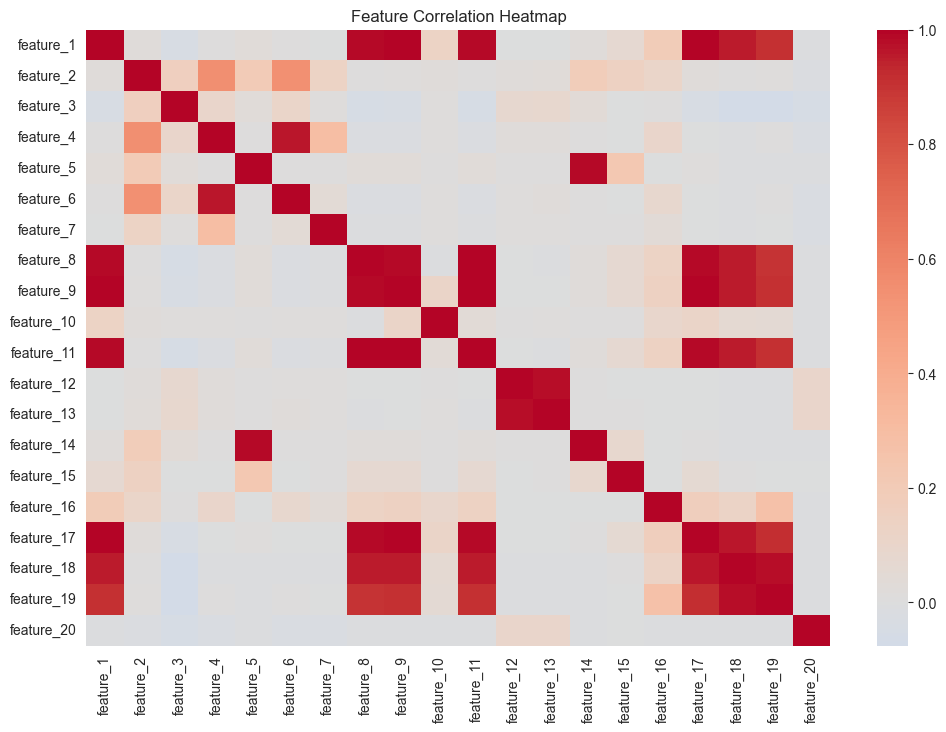

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.savefig(
    "../reports/figures/correlation_heatmap.png"
)

plt.show()

In [25]:
import pandas as pd

edges = pd.read_csv(
    "../data/raw/elliptic_txs_edgelist.csv"
)

print(edges.columns)

Index(['txId1', 'txId2'], dtype='object')


Key Findings

1. Dataset is highly imbalanced.

2. Fraud transactions represent a very small portion of labeled data.

3. Transaction activity varies across time steps.

4. Features appear normalized.

5. Certain features show noticeable differences between fraudulent and legitimate transactions.

6. Missing values are minimal and can be handled later during preprocessing.